In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("../data/processed_data.csv")
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default,...,EmploymentType_Unemployed,MaritalStatus_Married,MaritalStatus_Single,HasMortgage_Yes,HasDependents_Yes,LoanPurpose_Business,LoanPurpose_Education,LoanPurpose_Home,LoanPurpose_Other,HasCoSigner_Yes
0,56,85994,50587,520,80,4,15.23,36,0.44,0,...,0,0,0,1,1,0,0,0,1,1
1,69,50432,124440,458,15,1,4.81,60,0.68,0,...,0,1,0,0,0,0,0,0,1,1
2,46,84208,129188,451,26,3,21.17,24,0.31,1,...,1,0,0,1,1,0,0,0,0,0
3,32,31713,44799,743,0,3,7.07,24,0.23,0,...,0,1,0,0,0,1,0,0,0,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,...,1,0,0,0,1,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 29 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Age                           255347 non-null  int64  
 1   Income                        255347 non-null  int64  
 2   LoanAmount                    255347 non-null  int64  
 3   CreditScore                   255347 non-null  int64  
 4   MonthsEmployed                255347 non-null  int64  
 5   NumCreditLines                255347 non-null  int64  
 6   InterestRate                  255347 non-null  float64
 7   LoanTerm                      255347 non-null  int64  
 8   DTIRatio                      255347 non-null  float64
 9   Default                       255347 non-null  int64  
 10  Loan_to_Income                255347 non-null  float64
 11  Income_per_CreditLine         255347 non-null  float64
 12  Employment_Stability          255347 non-null  float64


# Splitting features into X and y

In [4]:
X = df.drop('Default', axis=1)
y = df['Default']

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Baseline Model Training

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [7]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(n_neighbors=5),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        class_weight='balanced',
        random_state=42
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    )
}

results = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Model: {name}")
    print(f"{'='*50}")

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    results.append([name, accuracy, precision, recall, f1])

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"])

    results_df = results_df.sort_values(by="Recall", ascending=False)
    print("\n\nModel Comparison:")
    print(results_df)


Model: Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.58      0.03      0.06      5900

    accuracy                           0.89     51070
   macro avg       0.73      0.52      0.50     51070
weighted avg       0.85      0.89      0.84     51070


Confusion Matrix:
[[45027   143]
 [ 5701   199]]


Model Comparison:
                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.885569   0.852294  0.885569  0.837939

Model: KNN

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.98      0.93     45170
           1       0.28      0.06      0.10      5900

    accuracy                           0.87     51070
   macro avg       0.58      0.52      0.52     51070
weighted avg       0.82      0.87      0.84     51070


Confusion Matrix:
[[44240   930]
 [ 5537   363]]


Model Co

`Recall is the most critical metric because failing to identify a defaulter (False Negative) can lead to direct financial losses for the bank. However, F1-score can also be used to balance recall with precision and evaluate performance on imbalanced datasets.`

# Hyperparameter Tuning

**Logistic Regression**

In [8]:
from sklearn.model_selection import GridSearchCV

lr_params = {
    'C':[0.01,0.1,1,10],
    'penalty':['l2']
}

In [9]:
lr_model = GridSearchCV(
    LogisticRegression(max_iter=1000),
    lr_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

In [10]:
lr_model.fit(X_train,y_train)

print(lr_model.best_params_)
print(lr_model.best_score_)

{'C': 0.01, 'penalty': 'l2'}
0.7358289358890328


**Decision Tree**

In [11]:
dt_params = {
    'max_depth':[5,10,15,20],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

In [12]:
dt_model = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)


In [13]:
dt_model.fit(X_train,y_train)

print(dt_model.best_params_)
print(dt_model.best_score_)

{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
0.7157563297841594


**Random Forest**

In [14]:
rf_params = {
    'n_estimators':[100,200,300],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}


In [15]:
rf_model = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

In [16]:
rf_model.fit(X_train, y_train)

print(rf_model.best_params_)
print(rf_model.best_score_)

{'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
0.7446728247881326


**Gradient Boosting**

In [17]:
gb_params = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.1],
    'max_depth':[3,5]
}


In [18]:
gb_model = GridSearchCV(
    GradientBoostingClassifier(),
    gb_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

In [19]:
gb_model.fit(X_train,y_train)

print(gb_model.best_params_)
print(gb_model.best_score_)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
0.7532287286485456


**KNN**

In [20]:
knn_params = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [21]:
knn_model = GridSearchCV(
    KNeighborsClassifier(),
    knn_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)


In [22]:
knn_model.fit(X_train, y_train)

print("Best Params:", knn_model.best_params_)
print("Best Score:", knn_model.best_score_)

Best Params: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'uniform'}
Best Score: 0.5977050096228425


**Adaboost**

In [23]:
ada_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}

In [24]:
ada_model = GridSearchCV(
    AdaBoostClassifier(random_state=42),
    ada_params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

In [25]:
ada_model.fit(X_train, y_train)

print("Best Params:", ada_model.best_params_)
print("Best Score:", ada_model.best_score_)

Best Params: {'learning_rate': 1.0, 'n_estimators': 200}
Best Score: 0.7521962256186531


# Evaluation Table after hyperparameter optimization

In [32]:
table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Decision Tree",
        "Random Forest",
        "AdaBoost",
        "Gradient Boosting",
    ],
    "ROC_AUC": [
        lr_model.best_score_,
        knn_model.best_score_,
        dt_model.best_score_,
        rf_model.best_score_,
        ada_model.best_score_,
        gb_model.best_score_,
    ]
})

table.sort_values(by="ROC_AUC", ascending=False)

,Model,ROC_AUC
5,Gradient Boosting,0.753229
4,AdaBoost,0.752196
3,Random Forest,0.744673
0,Logistic Regression,0.735829
2,Decision Tree,0.715756
1,KNN,0.597705


In [34]:
best_model = gb_model.best_estimator_
best_model

,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"init init: estimator or 'zero', default=NoneAn estimator object that is used to co

In [40]:
print("Best Model: Gradient Boosting")
print("ROC-AUC:", gb_model.best_score_)

Best Model: Gradient Boosting
ROC-AUC: 0.7532287286485456


In [41]:
import joblib
joblib.dump(best_model, "../model/loan_default_risk_model.pkl")

['../model/loan_default_risk_model.pkl']

**Feature Importance**

In [47]:
# Get feature importances
importance = gb_model.best_estimator_.feature_importances_

In [48]:
# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

In [49]:
# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

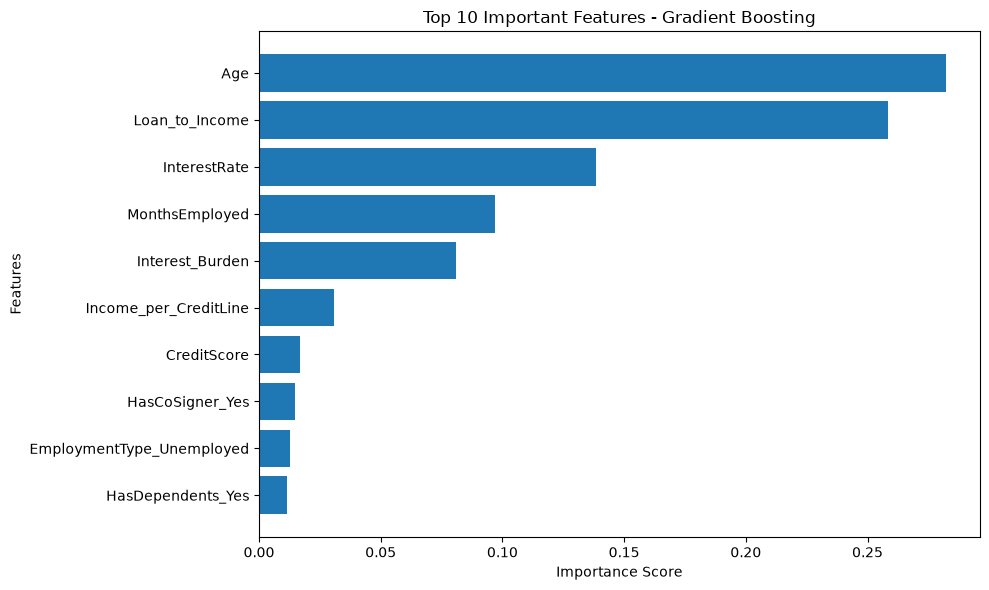

In [51]:
import matplotlib.pyplot as plt
# Plot Top 10 Features
plt.figure(figsize=(10,6))
plt.barh(
    feature_importance['Feature'][:10][::-1],
    feature_importance['Importance'][:10][::-1]
)

plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top 10 Important Features - Gradient Boosting')
plt.tight_layout()
plt.show()